In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [12]:
import pandas as pd
import glob
import os

# ===== Option A: If files are in one folder =====
files = glob.glob("/home/sanjeev/f110_ws/src/Data/*.csv")  # adjust path
print(f"Found {len(files)} files:")
for f in files:
    print(f)

Found 11 files:
/home/sanjeev/f110_ws/src/Data/training_data_f2.csv
/home/sanjeev/f110_ws/src/Data/training_data_berlin2.csv
/home/sanjeev/f110_ws/src/Data/merged_training_data_clean_v2.csv
/home/sanjeev/f110_ws/src/Data/training_data_berlin.csv
/home/sanjeev/f110_ws/src/Data/training_data_overtake.csv
/home/sanjeev/f110_ws/src/Data/training_data_hangar2.csv
/home/sanjeev/f110_ws/src/Data/merged_training_data_clean.csv
/home/sanjeev/f110_ws/src/Data/training_data_hangar.csv
/home/sanjeev/f110_ws/src/Data/training_data_f.csv
/home/sanjeev/f110_ws/src/Data/merged_training_data.csv
/home/sanjeev/f110_ws/src/Data/training_data_overtake2.csv


In [13]:
# ===== LOAD AND MERGE =====
df_list = []

for file in files:
    df_temp = pd.read_csv(file)
    df_temp['source_file'] = os.path.basename(file)  # track which file each row came from
    df_list.append(df_temp)
    print(f"Loaded: {os.path.basename(file)} → {len(df_temp)} rows")

# Merge all
df_merged = pd.concat(df_list, ignore_index=True)

print(f"\n✅ Total samples after merge: {len(df_merged)}")
print(df_merged.head())

Loaded: training_data_f2.csv → 13999 rows
Loaded: training_data_berlin2.csv → 13999 rows
Loaded: merged_training_data_clean_v2.csv → 79598 rows
Loaded: training_data_berlin.csv → 13999 rows
Loaded: training_data_overtake.csv → 13999 rows
Loaded: training_data_hangar2.csv → 13999 rows
Loaded: merged_training_data_clean.csv → 80544 rows
Loaded: training_data_hangar.csv → 13999 rows
Loaded: training_data_f.csv → 13999 rows
Loaded: merged_training_data.csv → 111992 rows
Loaded: training_data_overtake2.csv → 13999 rows

✅ Total samples after merge: 384126
        d_m  heading_error     kappa        vx  kappa_lookahead  steering  \
0 -0.038467       0.015067  0.000450  4.974809        -0.001123 -0.010345   
1 -0.012065       0.014001  0.000324  4.987936        -0.001381 -0.010345   
2 -0.038125       0.012453  0.000324  5.001854        -0.001381 -0.010345   
3 -0.011789       0.011016  0.000198  5.015545        -0.001639 -0.010701   
4 -0.038402       0.009162  0.000198  5.029361        -0.0

In [14]:
# Check shape
print("Shape:", df_merged.shape)

# Check distribution across files
print("\nSamples per source file:")
print(df_merged['source_file'].value_counts())

# Check for nulls
print("\nMissing values:")
print(df_merged.isnull().sum())

# Check column names are consistent
print("\nColumns:", df_merged.columns.tolist())

# Statistical summary
print("\nStatistics:")
print(df_merged.describe())

Shape: (384126, 7)

Samples per source file:
source_file
merged_training_data.csv             111992
merged_training_data_clean.csv        80544
merged_training_data_clean_v2.csv     79598
training_data_f2.csv                  13999
training_data_berlin2.csv             13999
training_data_berlin.csv              13999
training_data_overtake.csv            13999
training_data_hangar2.csv             13999
training_data_hangar.csv              13999
training_data_f.csv                   13999
training_data_overtake2.csv           13999
Name: count, dtype: int64

Missing values:
d_m                0
heading_error      0
kappa              0
vx                 0
kappa_lookahead    0
steering           0
source_file        0
dtype: int64

Columns: ['d_m', 'heading_error', 'kappa', 'vx', 'kappa_lookahead', 'steering', 'source_file']

Statistics:
                 d_m  heading_error          kappa             vx  \
count  384126.000000  384126.000000  384126.000000  384126.000000   
mean     

In [15]:
# ===== SHUFFLE (very important — removes map ordering bias) =====
df_merged = df_merged.sample(frac=1, random_state=42).reset_index(drop=True)

# ===== DROP source_file column before training =====
df_train = df_merged.drop(columns=['source_file'])

# ===== SAVE =====
df_train.to_csv("/home/sanjeev/f110_ws/src/Data/merged_training_data.csv", index=False)

print(f"✅ Merged dataset saved → {len(df_train)} total samples")

✅ Merged dataset saved → 384126 total samples


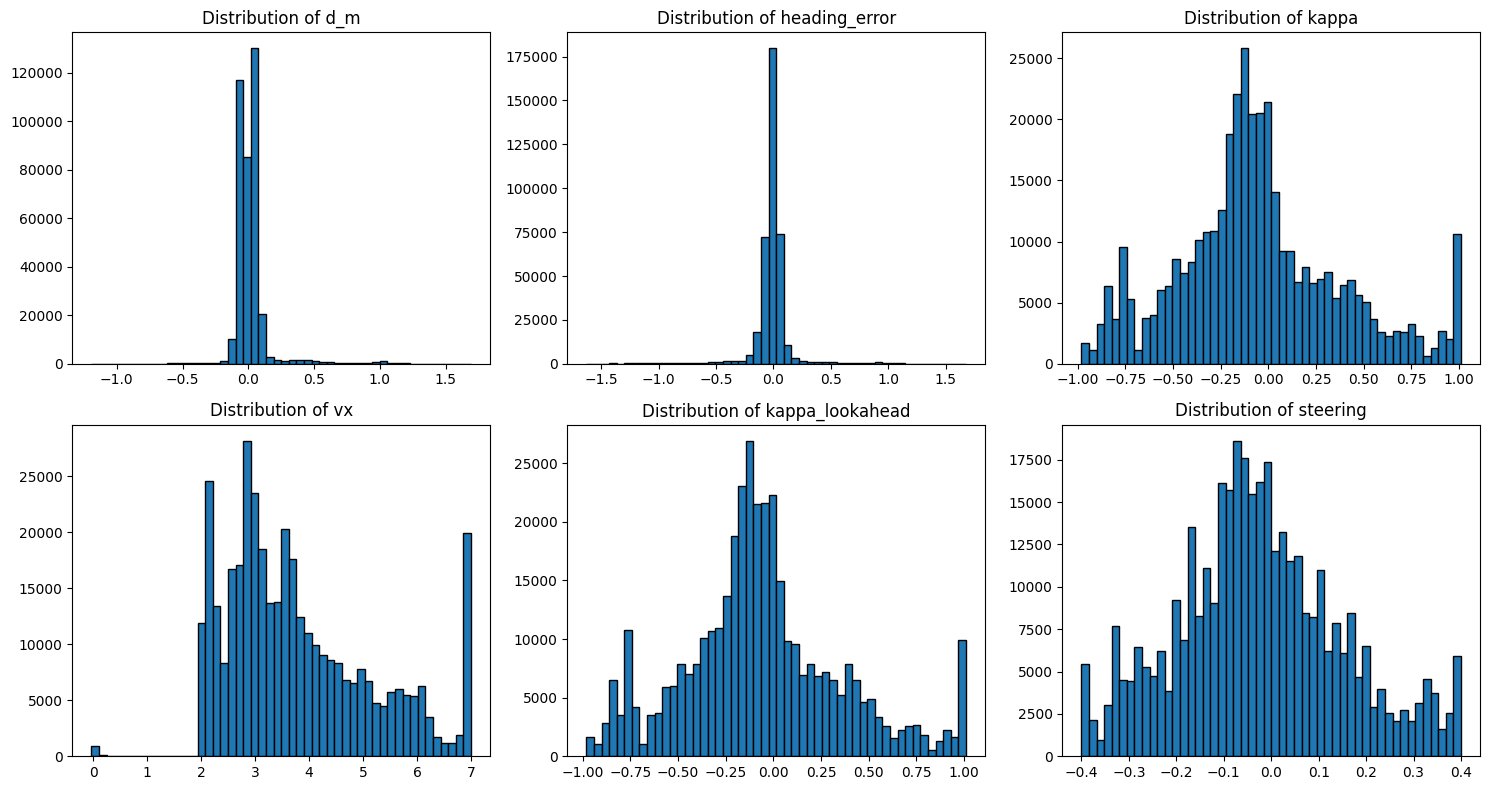

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

cols = ["d_m", "heading_error", "kappa", "vx", "kappa_lookahead", "steering"]

for i, col in enumerate(cols):
    axes[i//3][i%3].hist(df_merged[col], bins=50, edgecolor='black')
    axes[i//3][i%3].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

✅ Loaded | Rows: 384126
After dropna             : 384126 rows
After removing vx < 0.5  : 383030 rows
After removing kappa ±1  : 375374 rows
After removing kla ±1    : 368844 rows
After removing d_m > 0.5 : 362364 rows
After removing heading   : 333990 rows
After removing steer sat : 330902 rows
After removing vx > 8    : 330902 rows
After removing dupes     : 78639 rows  (removed 252263)

--- Verification (all must be 0) ---
  kappa >= 0.99        : 0
  kappa <= -0.99       : 0
  kappa_la >= 0.99     : 0
  kappa_la <= -0.99    : 0
  steering >= 0.39     : 0
  steering <= -0.39    : 0
  vx <= 0.5            : 0
  d_m abs >= 0.5       : 0
  NaN values           : 0

  FINAL ROW COUNT : 78639
              d_m  heading_error       kappa          vx  kappa_lookahead  \
count  78639.0000     78639.0000  78639.0000  78639.0000       78639.0000   
mean      -0.0051        -0.0124     -0.0752      3.7595          -0.0867   
std        0.0607         0.0490      0.3983      1.3249           0.

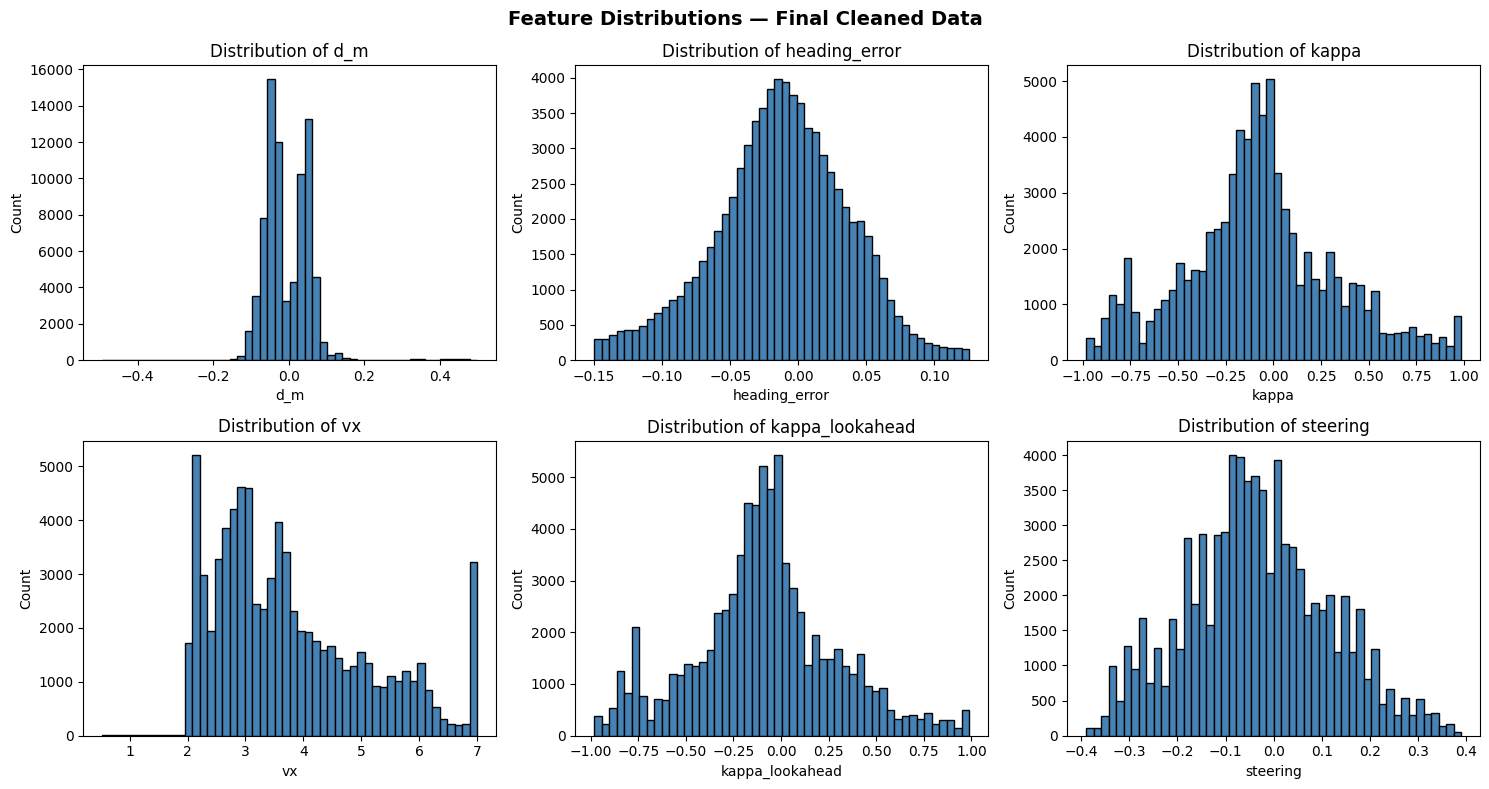


✅ Saved as merged_training_data_clean_final.csv


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================
# STEP 1: LOAD ORIGINAL MERGED DATASET
# =============================================================
df6 = pd.read_csv("merged_training_data.csv")
print(f"✅ Loaded | Rows: {len(df6)}")

# =============================================================
# STEP 2: DROP MISSING VALUES
# Removes rows with any NaN — caused by sensor/logging gaps
# =============================================================
df6 = df6.dropna()
print(f"After dropna             : {len(df6)} rows")

# =============================================================
# STEP 3: REMOVE STATIONARY DATA
# Car not moving → steering data is meaningless for training
# =============================================================
df6 = df6[df6['vx'] > 0.5]
print(f"After removing vx < 0.5  : {len(df6)} rows")

# =============================================================
# STEP 4: REMOVE KAPPA CLIPPING ARTIFACTS (BOTH SIDES)
# kappa hitting exactly ±1.0 is a saturation artifact
# Using abs() catches both +1.0 and -1.0 in one line
# =============================================================
df6 = df6[df6['kappa'].abs() < 0.99]
print(f"After removing kappa ±1  : {len(df6)} rows")

# =============================================================
# STEP 5: REMOVE KAPPA_LOOKAHEAD CLIPPING ARTIFACTS (BOTH SIDES)
# Same saturation issue as kappa
# =============================================================
df6 = df6[df6['kappa_lookahead'].abs() < 0.99]
print(f"After removing kla ±1    : {len(df6)} rows")

# =============================================================
# STEP 6: REMOVE EXTREME LATERAL DEVIATION
# d_m > ±0.5m means car was far off the racing line
# Likely caused by recovery moments or logging start/stop
# =============================================================
df6 = df6[df6['d_m'].abs() < 0.5]
print(f"After removing d_m > 0.5 : {len(df6)} rows")

# =============================================================
# STEP 7: REMOVE HEADING ERROR OUTLIERS (IQR METHOD)
# Large heading errors = car spinning or recovering
# IQR method removes statistically extreme values only
# =============================================================
Q1 = df6['heading_error'].quantile(0.25)
Q3 = df6['heading_error'].quantile(0.75)
IQR = Q3 - Q1
df6 = df6[
    (df6['heading_error'] >= Q1 - 1.5 * IQR) &
    (df6['heading_error'] <= Q3 + 1.5 * IQR)
]
print(f"After removing heading   : {len(df6)} rows")

# =============================================================
# STEP 8: REMOVE STEERING SATURATION AT ±0.4
# Steering was clipped to [-0.4, 0.4] in the controller
# Values at exactly ±0.4 are saturated, not true labels
# =============================================================
df6 = df6[df6['steering'].abs() < 0.39]
print(f"After removing steer sat : {len(df6)} rows")

# =============================================================
# STEP 9: REMOVE EXTREME SPEED VALUES
# vx > 8 m/s is beyond realistic range for this car
# =============================================================
df6 = df6[df6['vx'] <= 8.0]
print(f"After removing vx > 8    : {len(df6)} rows")

# =============================================================
# STEP 10: REMOVE DUPLICATE ROWS
# Exact duplicates from overlapping laps or logger repeats
# =============================================================
before = len(df6)
df6 = df6.drop_duplicates()
print(f"After removing dupes     : {len(df6)} rows  (removed {before - len(df6)})")

# =============================================================
# STEP 11: RESET INDEX
# Clean 0,1,2... index after all row removals
# =============================================================
df6 = df6.reset_index(drop=True)

# =============================================================
# STEP 12: VERIFY — ALL BOUNDARY COUNTS MUST BE 0
# =============================================================
print(f"\n--- Verification (all must be 0) ---")
print(f"  kappa >= 0.99        : {(df6['kappa'] >= 0.99).sum()}")
print(f"  kappa <= -0.99       : {(df6['kappa'] <= -0.99).sum()}")
print(f"  kappa_la >= 0.99     : {(df6['kappa_lookahead'] >= 0.99).sum()}")
print(f"  kappa_la <= -0.99    : {(df6['kappa_lookahead'] <= -0.99).sum()}")
print(f"  steering >= 0.39     : {(df6['steering'] >= 0.39).sum()}")
print(f"  steering <= -0.39    : {(df6['steering'] <= -0.39).sum()}")
print(f"  vx <= 0.5            : {(df6['vx'] <= 0.5).sum()}")
print(f"  d_m abs >= 0.5       : {(df6['d_m'].abs() >= 0.5).sum()}")
print(f"  NaN values           : {df6.isnull().sum().sum()}")

# =============================================================
# STEP 13: FINAL SUMMARY
# =============================================================
print(f"\n{'='*45}")
print(f"  FINAL ROW COUNT : {len(df6)}")
print(f"{'='*45}")
print(df6[["d_m", "heading_error", "kappa", "vx", "kappa_lookahead", "steering"]].describe().round(4))

# =============================================================
# STEP 14: PLOT FINAL DISTRIBUTIONS
# All plots should be smooth with no isolated boundary spikes
# =============================================================
cols = ["d_m", "heading_error", "kappa", "vx", "kappa_lookahead", "steering"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Feature Distributions — Final Cleaned Data", fontsize=14, fontweight='bold')

for i, col in enumerate(cols):
    axes[i//3][i%3].hist(df6[col], bins=50, edgecolor='black', color='steelblue')
    axes[i//3][i%3].set_title(f'Distribution of {col}')
    axes[i//3][i%3].set_xlabel(col)
    axes[i//3][i%3].set_ylabel('Count')

plt.tight_layout()
plt.show()

# =============================================================
# STEP 15: SAVE CLEANED DATASET
# Saved as new file — original merged_training_data.csv untouched
# =============================================================
df6.to_csv("merged_training_data_clean_final.csv", index=False)
print(f"\n✅ Saved as merged_training_data_clean_final.csv")

In [18]:
# ===== DEBUG: Check exact boundary values =====

print("=== KAPPA UNIQUE VALUES NEAR BOUNDARY ===")
print(df6[df6['kappa'].abs() >= 0.95]['kappa'].value_counts().head(10))

print("\n=== KAPPA_LOOKAHEAD UNIQUE VALUES NEAR BOUNDARY ===")
print(df6[df6['kappa_lookahead'].abs() >= 0.95]['kappa_lookahead'].value_counts().head(10))

print("\n=== KAPPA MIN/MAX ===")
print(f"  min: {df6['kappa'].min()}")
print(f"  max: {df6['kappa'].max()}")

print("\n=== KAPPA_LOOKAHEAD MIN/MAX ===")
print(f"  min: {df6['kappa_lookahead'].min()}")
print(f"  max: {df6['kappa_lookahead'].max()}")

=== KAPPA UNIQUE VALUES NEAR BOUNDARY ===
kappa
 0.980087    151
 0.956492    136
 0.984868    135
 0.973446    134
-0.955320    132
-0.981590    132
-0.971877    129
 0.958918    120
 0.973913    114
Name: count, dtype: int64

=== KAPPA_LOOKAHEAD UNIQUE VALUES NEAR BOUNDARY ===
kappa_lookahead
-0.955320    127
-0.971877    127
 0.988186    126
 0.987576    123
-0.981590    119
 0.961007    102
 0.958918     73
 0.973913     66
Name: count, dtype: int64

=== KAPPA MIN/MAX ===
  min: -0.9815898520377128
  max: 0.984867885352384

=== KAPPA_LOOKAHEAD MIN/MAX ===
  min: -0.9815898520377128
  max: 0.9881863245847124
